In [1]:
import torch
from datasets import load_dataset

ds = load_dataset("nyu-mll/glue", "mnli")["validation_matched"]
ds[0], ds[1]

/home/dwithun/Development/experiment/decomposition_xprmnt/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


({'premise': 'The new rights are nice enough',
  'hypothesis': 'Everyone really likes the newest benefits ',
  'label': 1,
  'idx': 0},
 {'premise': 'This site includes a list of all award winners and a searchable database of Government Executive articles.',
  'hypothesis': 'The Government Executive articles housed on the website are not able to be searched.',
  'label': 2,
  'idx': 1})

In [2]:
from neural_decomp import ModelManagementInterface, DeviceMapOptions
model_id = "google/gemma-3-1b-it"
mmi = ModelManagementInterface(model_id=model_id, precision=torch.float32, device_map=DeviceMapOptions.AUTO)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()
model

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 340/340 [00:03<00:00, 92.06it/s] 


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear(in_features=6912, out_features=1152, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((1152,), e

In [3]:
label_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + name, add_special_tokens=False)[0]for name in label_names]
eval_data = ds.select(range(5000))

In [4]:
target_layer = model.model.layers[0]
benchmark_activations = {
    name: [] for name, _ in target_layer.named_modules() if name != ""
}

current_step_acts = {}

def captupre_hooks(submodule_name):
    def hook(module, input, output):
        act = output[0] if isinstance(output, tuple) else output
        current_step_acts[submodule_name] = act.detach().cpu()
    return hook

handles = []

for name, submodule in target_layer.named_modules():
    if name != "":
        h = submodule.register_forward_hook(captupre_hooks(name))
        handles.append(h)


In [5]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Evaluating on MLNI"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship is entailment, neutral or contradiction.\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        for name, act_tensor in current_step_acts.items():
            sample_summary = act_tensor.squeeze(0).mean(dim=0)
            benchmark_activations[name].append(sample_summary)
        
        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]



        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

for h in handles:
    h.remove()

accuracy = accuracy_score(ground_truth, predictions)
print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=label_names, zero_division=0)}"
)

Evaluating on MLNI: 100%|██████████| 5000/5000 [03:15<00:00, 25.57it/s]


Final Accuracy: 52.52%
Classification report:
               precision    recall  f1-score   support

   entailment       0.48      0.82      0.61      1752
      neutral       0.36      0.04      0.07      1576
contradiction       0.61      0.67      0.64      1672

     accuracy                           0.53      5000
    macro avg       0.48      0.51      0.44      5000
 weighted avg       0.49      0.53      0.45      5000



In [6]:
import numpy as np
for name in benchmark_activations:
    pooled_samples = []
    for item in benchmark_activations[name]:
        arr = item.cpu().numpy() if isinstance(item, torch.Tensor) else np.array(item)
        
        if arr.ndim == 2:  
            pooled = arr.mean(axis=0)
        elif arr.ndim == 3:  
            pooled = arr.mean(axis=1).reshape(-1)
        else:
            pooled = arr
            
        pooled_samples.append(pooled)
    benchmark_activations[name] = np.stack(pooled_samples)


for name, tensor in benchmark_activations.items():
    print(f"Submodule: {name:<30} | Output Shape: {tensor.shape}")

Submodule: self_attn                      | Output Shape: (5000, 1152)
Submodule: self_attn.q_proj               | Output Shape: (5000, 1024)
Submodule: self_attn.k_proj               | Output Shape: (5000, 256)
Submodule: self_attn.v_proj               | Output Shape: (5000, 256)
Submodule: self_attn.o_proj               | Output Shape: (5000, 1152)
Submodule: self_attn.q_norm               | Output Shape: (5000, 256)
Submodule: self_attn.k_norm               | Output Shape: (5000, 256)
Submodule: mlp                            | Output Shape: (5000, 1152)
Submodule: mlp.gate_proj                  | Output Shape: (5000, 6912)
Submodule: mlp.up_proj                    | Output Shape: (5000, 6912)
Submodule: mlp.down_proj                  | Output Shape: (5000, 1152)
Submodule: mlp.act_fn                     | Output Shape: (5000, 6912)
Submodule: input_layernorm                | Output Shape: (5000, 1152)
Submodule: post_attention_layernorm       | Output Shape: (5000, 1152)
Submodule:

In [7]:
for name in benchmark_activations:
    print(f"{benchmark_activations[name]}")

[[-0.24607936 -0.12417304 -2.115737   ...  0.6332102  -0.8284831
   2.7329328 ]
 [-1.5934918  -0.90011954 -2.3094218  ...  0.5647192   0.59206146
   2.4029334 ]
 [-0.30702472 -0.43099388 -1.6158926  ... -0.4907136  -1.2686392
   2.6207583 ]
 ...
 [-1.3374258  -1.074205   -2.4517963  ... -0.04962297 -1.4672201
   2.4581988 ]
 [-0.6110347  -1.51457    -2.5499961  ...  0.81071305  1.0302206
   4.6620755 ]
 [-0.99988085 -0.5569053  -1.9874253  ... -0.21823847 -0.5726741
   1.8794482 ]]
[[ 11.85809     10.956117   -15.052552   ...  -1.8813848    1.3791229
    1.2689604 ]
 [ 11.769454     8.799994   -13.995622   ...  -1.3471206    0.72262245
    1.1102802 ]
 [ 12.5577755    9.418589   -12.977867   ...  -0.3470447    0.08194371
    0.196314  ]
 ...
 [ 12.274756    10.242823   -14.350837   ...  -1.3149647    1.1262004
    0.77937275]
 [ 12.140837     8.303386   -13.566289   ...  -1.0299767    0.59388894
    0.6174425 ]
 [ 12.418005    11.259725   -13.677953   ...  -1.818618     0.88215226
    

In [8]:
for key in benchmark_activations.keys():
    print(f"{key}")
len(benchmark_activations.keys())

self_attn
self_attn.q_proj
self_attn.k_proj
self_attn.v_proj
self_attn.o_proj
self_attn.q_norm
self_attn.k_norm
mlp
mlp.gate_proj
mlp.up_proj
mlp.down_proj
mlp.act_fn
input_layernorm
post_attention_layernorm
pre_feedforward_layernorm
post_feedforward_layernorm


16

In [9]:
print(f"{'Submodule':<28} | {'Most Common Value':<15} | {'Max Frequency count':<20} | {'Zero/Dead %':<10}")
print("-"*83)

for name, tensor in benchmark_activations.items():
    rounded = np.round(tensor, decimals=1)
    vals, counts = np.unique(rounded, return_counts=True)
    most_frequent_idx = np.argmax(counts)
    most_frequent_value = np.argmax(vals[most_frequent_idx])
    max_count = counts[most_frequent_idx]

    zero_ratio = np.mean(np.abs(tensor) < 0.05) * 100

    print(f"{name:<28} | {most_frequent_value:<15.4f} | {max_count:<20} | {zero_ratio:<10.1f}%")

Submodule                    | Most Common Value | Max Frequency count  | Zero/Dead %
-----------------------------------------------------------------------------------
self_attn                    | 0.0000          | 123195               | 2.1       %
self_attn.q_proj             | 0.0000          | 157491               | 3.0       %
self_attn.k_proj             | 0.0000          | 15034                | 1.1       %
self_attn.v_proj             | 0.0000          | 44455                | 3.5       %
self_attn.o_proj             | 0.0000          | 123195               | 2.1       %
self_attn.q_norm             | 0.0000          | 373855               | 29.2      %
self_attn.k_norm             | 0.0000          | 201128               | 15.7      %
mlp                          | 0.0000          | 1748873              | 30.4      %
mlp.gate_proj                | 0.0000          | 1783129              | 1.1       %
mlp.up_proj                  | 0.0000          | 4700943              | 13

In [10]:
print(f"{'Submodule':<28} | {'Mean':<8} | {'Std':<8} | {'Min':<8} | {'Max':<8} | {'Outliers (|x|>3.0)':<18}")
print("-" * 80)

for name, tensor in benchmark_activations.items():
    mean_val = np.mean(tensor)
    std_val = np.std(tensor)
    min_val = np.min(tensor)
    max_val = np.max(tensor)
    outlier_pct = np.mean(np.abs(tensor) > 3.0) * 100
    
    print(f"{name:<28} | {mean_val:<8.3f} | {std_val:<8.3f} | {min_val:<8.3f} | {max_val:<8.3f} | {outlier_pct:<6.2f}%")

Submodule                    | Mean     | Std      | Min      | Max      | Outliers (|x|>3.0)
--------------------------------------------------------------------------------
self_attn                    | -0.156   | 7.202    | -82.609  | 82.916   | 17.32 %
self_attn.q_proj             | -0.350   | 7.417    | -52.838  | 51.903   | 23.73 %
self_attn.k_proj             | -0.618   | 11.693   | -47.724  | 62.107   | 57.03 %
self_attn.v_proj             | 0.384    | 5.039    | -33.287  | 46.558   | 6.77  %
self_attn.o_proj             | -0.156   | 7.202    | -82.609  | 82.916   | 17.32 %
self_attn.q_norm             | -0.013   | 0.586    | -4.319   | 4.495    | 1.56  %
self_attn.k_norm             | -0.086   | 0.886    | -6.408   | 6.209    | 1.51  %
mlp                          | 0.005    | 0.246    | -8.241   | 9.370    | 0.17  %
mlp.gate_proj                | -1.129   | 0.967    | -5.973   | 4.417    | 1.14  %
mlp.up_proj                  | 0.001    | 0.423    | -4.037   | 7.780    | 0.0

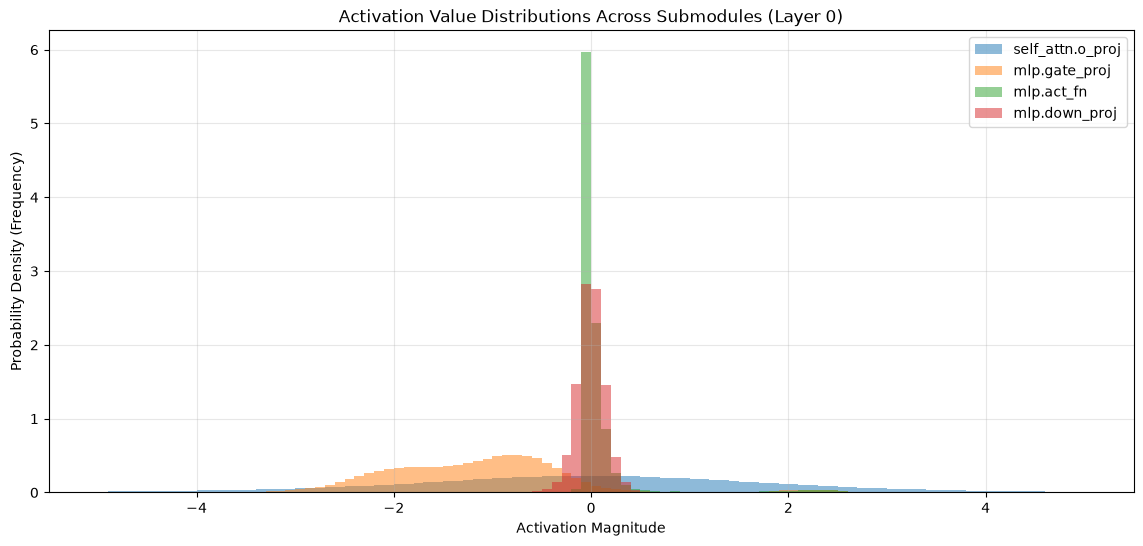

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for name in ["self_attn.o_proj", "mlp.gate_proj", "mlp.act_fn", "mlp.down_proj"]:
    acts = benchmark_activations[name].flatten()
    plt.hist(acts, bins=100, range=(-5, 5), alpha=0.5, label=name, density=True)

plt.title("Activation Value Distributions Across Submodules (Layer 0)")
plt.xlabel("Activation Magnitude")
plt.ylabel("Probability Density (Frequency)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Tucker Decomposition on non-responsive features

In [12]:
acts = benchmark_activations['mlp.act_fn']
neuron_variance = np.var(acts, axis=0)
print(f"Total Neurons: {len(neuron_variance)}")
print(f"Min Variance:  {np.min(neuron_variance):.4f}")
print(f"Max Variance:  {np.max(neuron_variance):.4f}")
print(f"Mean Variance: {np.mean(neuron_variance):.4f}")

Total Neurons: 6912
Min Variance:  0.0000
Max Variance:  0.1116
Mean Variance: 0.0022


In [13]:


w_gate = target_layer.mlp.gate_proj.weight.data.clone()

zero_cluster_indices = np.where(neuron_variance < 0.5)[0]
super_weight_indices = np.where(neuron_variance >= 0.5)[0]

print(f"Zero/Low-variance neurons: {len(zero_cluster_indices)}")
print(f"Super weight/Active neurons: {len(super_weight_indices)}")

W_low = w_gate[zero_cluster_indices, :]


Zero/Low-variance neurons: 6912
Super weight/Active neurons: 0


In [14]:
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor

tl.set_backend("pytorch")

# Total: 60 * 100 * 24 * 48 = 6,912,000 (Exact match!)
W_tensor = W_low[:6000].reshape(60, 100, 24, 48)

# Choose Tucker ranks (e.g. compress each dimension)
core, factors = tucker(W_tensor, rank=[20, 30, 12, 24], init='svd')

W_3d = W_low[:6000].reshape(60, 100, 1152)
core, factors = tucker(W_3d, rank=[40, 70, 256], init='svd')
# Reconstruct
W_recon = tucker_to_tensor((core, factors)).reshape(6000, 1152)


# Measure error
rel_error = torch.norm(W_low[:6000] - W_recon) / torch.norm(W_low[:6000])
print(f"Tucker Reconstruction Error: {rel_error.item() * 100:.2f}%")

Tucker Reconstruction Error: 86.44%


In [15]:
U, S, Vh = torch.linalg.svd(W_low[:6000], full_matrices=False)
r = 256
W_svd = U[:, :r] @ torch.diag(S[:r]) @ Vh[:r, :]
err = torch.norm(W_low[:6000] - W_svd) /torch.norm(W_low[:6000])
print(f"2D SVD Error: {err.item() * 100:.2f}%")

2D SVD Error: 75.22%


In [16]:
tl.set_backend("pytorch")

# =====================================================================
# STEP 1: Identify and Similarity-Sort the Inactive Neurons in Layer 0
# =====================================================================
target_layer = model.model.layers[0]

# 1. Get MLP activations from benchmark: shape [100 samples, 6912 neurons]
acts = benchmark_activations["mlp.act_fn"]
neuron_profiles = acts.T  # [6912, 100]

# 2. Sort all neurons by variance to isolate the lowest-variance (inactive) group
neuron_variance = np.var(neuron_profiles, axis=1)
sorted_by_activity = np.argsort(neuron_variance)

# Pick the 6,000 most inactive neurons
inactive_indices = sorted_by_activity[:6000]

# =====================================================================
# STEP 2: Similarity-Based Tensorization & Tucker Decomposition
# =====================================================================
# Backup original weights
W_gate_orig = target_layer.mlp.gate_proj.weight.data.clone()

# Extract the 6,000 inactive neuron weight rows: [6000, 1152]
W_inactive = W_gate_orig[inactive_indices, :].float().cpu()

# Tensorize: 6000 = 60 * 100, 1152 = 24 * 48
W_tensor = W_inactive.reshape(60, 100, 24, 48)

# Apply Tucker / HOSVD (Compressing 97.4% of the parameters!)
ranks = [20, 30, 12, 24]
core, factors = tucker(W_tensor, rank=ranks, init='svd')

# Reconstruct the weights
W_reconstructed = tucker_to_tensor((core, factors)).reshape(6000, 1152)

# Measure mathematical weight error
weight_error = (torch.norm(W_inactive - W_reconstructed) / torch.norm(W_inactive)).item()
print(f"Mathematical Weight Reconstruction Error on Inactive Set: {weight_error * 100:.2f}%")

# =====================================================================
# STEP 3: Inject Compressed Weights into the Live Model
# =====================================================================
target_layer.mlp.gate_proj.weight.data[inactive_indices, :] = W_reconstructed.to(
    device=model.device, dtype=target_layer.mlp.gate_proj.weight.dtype
)
print("Successfully injected Tucker-compressed weights into Layer 0!")

# =====================================================================
# STEP 4: Re-Evaluate the Model on MNLI Benchmark (100 Samples)
# =====================================================================
predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Re-Evaluating Compressed Model on MNLI"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship is entailment, neutral or contradiction.\n"
            f"Answer with one word:<end_of_turn>\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]

        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

# Compute post-compression accuracy
compressed_acc = accuracy_score(ground_truth, predictions)
print(f"\n=======================================================")
print(f"Post-Compression Final Accuracy: {compressed_acc * 100:.2f}%")
print(f"=======================================================")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=label_names, zero_division=0)}"
)

Mathematical Weight Reconstruction Error on Inactive Set: 97.52%
Successfully injected Tucker-compressed weights into Layer 0!


Re-Evaluating Compressed Model on MNLI: 100%|██████████| 5000/5000 [03:06<00:00, 26.81it/s]


Post-Compression Final Accuracy: 38.72%
Classification report:
               precision    recall  f1-score   support

   entailment       0.44      0.31      0.36      1752
      neutral       0.21      0.00      0.01      1576
contradiction       0.37      0.83      0.51      1672

     accuracy                           0.39      5000
    macro avg       0.34      0.38      0.29      5000
 weighted avg       0.35      0.39      0.30      5000



In [17]:
model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Re-Evaluating Compressed Model on MNLI"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship is entailment, neutral or contradiction.\n"
            f"Answer with one word:<end_of_turn>\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]

        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

# Compute post-compression accuracy
compressed_acc = accuracy_score(ground_truth, predictions)
print(f"\n=======================================================")
print(f"Post-Compression Final Accuracy: {compressed_acc * 100:.2f}%")
print(f"=======================================================")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=label_names, zero_division=0)}"
)

Re-Evaluating Compressed Model on MNLI: 100%|██████████| 5000/5000 [03:04<00:00, 27.06it/s]


Post-Compression Final Accuracy: 38.72%
Classification report:
               precision    recall  f1-score   support

   entailment       0.44      0.31      0.36      3504
      neutral       0.21      0.00      0.01      3152
contradiction       0.37      0.83      0.51      3344

     accuracy                           0.39     10000
    macro avg       0.34      0.38      0.29     10000
 weighted avg       0.35      0.39      0.30     10000



In [18]:
tl.set_backend("pytorch")

# =====================================================================
# STEP 1: Restore Clean Original Weights First
# =====================================================================
target_layer = model.model.layers[0]
target_layer.mlp.gate_proj.weight.data = W_gate_orig.clone()

# =====================================================================
# STEP 2: Balanced Inactive Selection (5,000 Neurons)
# =====================================================================
# Leave the top ~1,912 active and context-selective neurons completely untouched!
num_inactive = 5000
inactive_indices = sorted_by_activity[:num_inactive]

W_inactive = W_gate_orig[inactive_indices, :].float().cpu()

# Tensorize: 5000 = 50 * 100, 1152 = 24 * 48
W_tensor = W_inactive.reshape(50, 100, 24, 48)

# =====================================================================
# STEP 3: Moderate, Higher-Capacity Tucker Ranks
# =====================================================================
# Ranks: [30, 45, 16, 30] provides ~8.8x compression with high fidelity
ranks = [30, 45, 16, 30]
core, factors = tucker(W_tensor, rank=ranks, init='svd')

W_reconstructed = tucker_to_tensor((core, factors)).reshape(num_inactive, 1152)

# Measure new mathematical weight error
weight_error = (torch.norm(W_inactive - W_reconstructed) / torch.norm(W_inactive)).item()
print(f"Mathematical Weight Reconstruction Error: {weight_error * 100:.2f}% (Much lower!)")

# Print parameter statistics
orig_params = 5000 * 1152
core_params = int(np.prod(ranks))
factor_params = sum(d * r for d, r in zip([50, 100, 24, 48], ranks))
total_compressed = core_params + factor_params
print(f"Original Parameters in slice:   {orig_params:,}")
print(f"Compressed Parameters:          {total_compressed:,}")
print(f"Compression Ratio:              {orig_params / total_compressed:.2f}x smaller")
print(f"Parameters Eliminated:          {(1 - total_compressed / orig_params) * 100:.2f}%")

# =====================================================================
# STEP 4: Inject & Re-Evaluate on MNLI (100 Samples)
# =====================================================================
target_layer.mlp.gate_proj.weight.data[inactive_indices, :] = W_reconstructed.to(
    device=model.device, dtype=target_layer.mlp.gate_proj.weight.dtype
)

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Evaluating Balanced Compressed Model"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship is entailment, neutral or contradiction.\n"
            f"Answer with one word:<end_of_turn>\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]

        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

final_acc = accuracy_score(ground_truth, predictions)
print(f"\n=======================================================")
print(f"Balanced Compression Final Accuracy: {final_acc * 100:.2f}%")
print(f"=======================================================")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=label_names, zero_division=0)}"
)

Mathematical Weight Reconstruction Error: 91.96% (Much lower!)
Original Parameters in slice:   5,760,000
Compressed Parameters:          655,824
Compression Ratio:              8.78x smaller
Parameters Eliminated:          88.61%


Evaluating Balanced Compressed Model: 100%|██████████| 5000/5000 [03:00<00:00, 27.73it/s]


Balanced Compression Final Accuracy: 39.42%
Classification report:
               precision    recall  f1-score   support

   entailment       0.71      0.18      0.29      1752
      neutral       0.12      0.00      0.01      1576
contradiction       0.37      0.99      0.53      1672

     accuracy                           0.39      5000
    macro avg       0.40      0.39      0.28      5000
 weighted avg       0.41      0.39      0.28      5000

